In [2]:
#Logistic Regression Implementation

In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.datasets import make_classification

In [3]:
#Create The Dataset
X,y = make_classification(n_samples=1000,n_features=10,n_classes=2,random_state=15)

In [4]:
X.shape
y.shape

(1000,)

In [5]:
pd.DataFrame(X)

,0,1,2,3,4,5,6,7,8,9
0,-0.377957,1.043895,1.043494,-0.101838,-1.617442,0.402713,0.913601,-0.067192,0.175471,-1.049646
1,-0.325259,1.276263,-0.686123,-2.463205,-0.489426,-0.240715,-1.469496,1.006633,-0.833692,0.957744
2,0.739019,-0.600903,-0.177294,1.335714,-0.817332,-0.790047,1.457365,-0.218981,0.878643,-1.257740
3,0.474312,-1.103002,1.189936,-0.800186,0.912377,-0.406451,-1.130950,1.985111,1.379029,1.041768
4,0.927365,1.114796,0.080284,1.261064,0.761179,0.921563,0.440832,0.184645,-1.567739,-0.142107
...,...,...,...,...,...,...,...,...,...,...
995,1.538272,0.171629,0.075371,-0.957658,-1.066219,1.158096,-0.036964,0.123689,0.927871,-0.225003
996,-0.060266,0.095018,-0.271685,1.830560,0.219445,-0.341269,1.180088,-0.216876,-1.752938,-0.810152
997,0.675563,-0.538420,-1.299500,0.747835,1.733898,-0.268044,-0.520953,2.043336,0.947388,0.790354
998,2.629710,-2.452899,-1.359785,1.592065,0.854157,1.618828,0.621701,0.378898,-1.971894,-0.252250


In [6]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.30,random_state=42)

In [7]:
#Implementing Logistic Regression
from sklearn.linear_model import LogisticRegression

logistic = LogisticRegression()

In [8]:
logistic.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [9]:
y_pred = logistic.predict(X_test)
print(y_pred)

[0 0 0 1 1 0 0 1 1 1 1 0 1 0 1 0 0 1 0 1 1 1 1 0 0 0 0 0 0 1 1 0 1 1 1 0 1
 1 0 0 0 0 0 1 0 1 1 1 1 0 1 1 1 1 1 1 1 0 1 0 1 0 0 0 1 1 0 0 1 0 0 0 1 0
 1 0 1 0 0 0 0 0 0 0 1 0 1 0 0 1 1 1 0 1 1 1 0 1 1 1 1 0 0 0 0 0 1 0 0 0 1
 1 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 1 1 0 1 0 0 1 1 0 0 1 1 1 1 0 0 0 1 1
 0 1 0 0 1 0 0 0 1 1 0 1 0 0 0 1 0 1 1 0 0 1 0 1 1 0 1 1 0 0 1 1 0 1 0 1 0
 0 1 1 0 1 1 1 1 0 1 1 1 1 1 0 1 1 0 1 0 0 1 0 1 0 1 1 0 1 0 1 0 0 0 0 0 0
 0 1 0 0 0 0 0 1 0 1 0 0 1 0 1 1 0 0 1 1 1 0 1 1 0 0 1 1 0 1 1 0 0 1 0 0 1
 0 0 1 0 1 0 1 0 0 1 1 0 0 1 1 0 1 1 1 0 1 1 0 0 0 1 0 0 0 1 0 0 1 0 1 0 1
 0 1 0 0]


In [10]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [11]:
score = accuracy_score(y_test,y_pred)
print(score)
cm = confusion_matrix(y_test,y_pred)
print(cm)
print(classification_report(y_test,y_pred))

0.9166666666666666
[[146  11]
 [ 14 129]]
              precision    recall  f1-score   support

           0       0.91      0.93      0.92       157
           1       0.92      0.90      0.91       143

    accuracy                           0.92       300
   macro avg       0.92      0.92      0.92       300
weighted avg       0.92      0.92      0.92       300



In [12]:
#For Random_state=42 Acc=0.86
#For Random_state=15 Acc=0.9166666666666666

In [13]:
#Hyper Paramter Tuning and Cross Validation
model = LogisticRegression()
penalty =['l1', 'l2', 'elasticnet']
c_values = [100,10,1.0,0.1,0.01]
solver = ['lbfgs', 'liblinear', 'newton-cg', 'sag', 'saga']

In [14]:
params = dict(penalty=penalty,C= c_values,solver=solver)

In [15]:
from sklearn.model_selection import StratifiedKFold
cv = StratifiedKFold()

In [16]:
#Grid Search CV
from sklearn.model_selection import GridSearchCV
grid =GridSearchCV(estimator=model,param_grid=params,scoring='accuracy',cv=cv,n_jobs=-1)

In [17]:
grid

,estimator,LogisticRegression()
,param_grid,"{'C': [100, 10, ...], 'penalty': ['l1', 'l2', ...], 'solver': ['lbfgs', 'liblinear', ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo...shuffle=False)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [18]:
grid.fit(X_train,y_train)

,estimator,LogisticRegression()
,param_grid,"{'C': [100, 10, ...], 'penalty': ['l1', 'l2', ...], 'solver': ['lbfgs', 'liblinear', ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo...shuffle=False)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l1'


In [19]:
grid.best_params_

{'C': 0.01, 'penalty': 'l1', 'solver': 'saga'}

In [20]:
grid.best_score_

np.float64(0.9242857142857142)

In [21]:
y_pred = grid.predict(X_test)

In [22]:
score = accuracy_score(y_test,y_pred)
print(score)
cm = confusion_matrix(y_test,y_pred)
print(cm)
print(classification_report(y_test,y_pred))

0.92
[[149   8]
 [ 16 127]]
              precision    recall  f1-score   support

           0       0.90      0.95      0.93       157
           1       0.94      0.89      0.91       143

    accuracy                           0.92       300
   macro avg       0.92      0.92      0.92       300
weighted avg       0.92      0.92      0.92       300



In [23]:
#Randomized SearchCV
from sklearn.model_selection import RandomizedSearchCV

model = LogisticRegression()
randomcv = RandomizedSearchCV(estimator=model,param_distributions = params,cv=5,scoring='accuracy')


In [24]:
randomcv.fit(X_train,y_train)

,estimator,LogisticRegression()
,param_distributions,"{'C': [100, 10, ...], 'penalty': ['l1', 'l2', ...], 'solver': ['lbfgs', 'liblinear', ...]}"
,n_iter,10
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [25]:
randomcv.best_score_

np.float64(0.9128571428571428)

In [26]:
randomcv.best_params_

{'solver': 'liblinear', 'penalty': 'l1', 'C': 10}

In [27]:
y_pred = randomcv.predict(X_test)

In [28]:
score = accuracy_score(y_test,y_pred)
print(score)
cm = confusion_matrix(y_test,y_pred)
print(cm)
print(classification_report(y_test,y_pred))

0.9166666666666666
[[146  11]
 [ 14 129]]
              precision    recall  f1-score   support

           0       0.91      0.93      0.92       157
           1       0.92      0.90      0.91       143

    accuracy                           0.92       300
   macro avg       0.92      0.92      0.92       300
weighted avg       0.92      0.92      0.92       300



In [29]:
#Multi-Class Classification

In [30]:
#Create The Dataset
X,y = make_classification(n_samples=1000,n_features=10,n_informative=3,n_classes=3,random_state=15)

In [31]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.30,random_state=100)

In [32]:
from sklearn.linear_model import LogisticRegression
logistic = LogisticRegression(multi_class='ovr')
logistic.fit(X_train,y_train)
y_pred = logistic.predict(X_test)

In [33]:
score = accuracy_score(y_test,y_pred)
print(score)
cm = confusion_matrix(y_test,y_pred)
print(cm)
print(classification_report(y_test,y_pred))

0.7866666666666666
[[81 19  4]
 [ 4 70 21]
 [ 6 10 85]]
              precision    recall  f1-score   support

           0       0.89      0.78      0.83       104
           1       0.71      0.74      0.72        95
           2       0.77      0.84      0.81       101

    accuracy                           0.79       300
   macro avg       0.79      0.79      0.79       300
weighted avg       0.79      0.79      0.79       300



In [34]:
from sklearn.model_selection import StratifiedKFold
cv = StratifiedKFold()

In [35]:
#Grid Search CV
from sklearn.model_selection import GridSearchCV
grid =GridSearchCV(estimator=model,param_grid=params,scoring='accuracy',cv=cv,n_jobs=-1)

In [36]:
grid.fit(X_train,y_train)
grid.predict(X_test)
grid.best_score_

np.float64(0.7957142857142857)

In [169]:
score = accuracy_score(y_test,y_pred)
print(score)
cm = confusion_matrix(y_test,y_pred)
print(cm)
print(classification_report(y_test,y_pred))

0.7866666666666666
[[81 19  4]
 [ 4 70 21]
 [ 6 10 85]]
              precision    recall  f1-score   support

           0       0.89      0.78      0.83       104
           1       0.71      0.74      0.72        95
           2       0.77      0.84      0.81       101

    accuracy                           0.79       300
   macro avg       0.79      0.79      0.79       300
weighted avg       0.79      0.79      0.79       300



In [37]:
#Randomized SearchCV
from sklearn.model_selection import RandomizedSearchCV

model = LogisticRegression()
randomcv = RandomizedSearchCV(estimator=model,param_distributions = params,cv=5,scoring='accuracy')


In [38]:
grid.fit(X_train,y_train)
grid.predict(X_test)
grid.best_score_

np.float64(0.7957142857142857)

In [39]:
score = accuracy_score(y_test,y_pred)
print(score)
cm = confusion_matrix(y_test,y_pred)
print(cm)
print(classification_report(y_test,y_pred))

0.7866666666666666
[[81 19  4]
 [ 4 70 21]
 [ 6 10 85]]
              precision    recall  f1-score   support

           0       0.89      0.78      0.83       104
           1       0.71      0.74      0.72        95
           2       0.77      0.84      0.81       101

    accuracy                           0.79       300
   macro avg       0.79      0.79      0.79       300
weighted avg       0.79      0.79      0.79       300



In [40]:
#Logistic Regression for Imbalanced Dataset
from collections import Counter
from sklearn.datasets import make_classification

In [41]:
X,y = make_classification(n_samples=10000,n_features =2,n_clusters_per_class=1,n_redundant=0,weights=[0.99],random_state=10)

In [42]:
Counter(y)

Counter({np.int64(0): 9846, np.int64(1): 154})

In [43]:
import seaborn as sns

<Axes: xlabel='0', ylabel='1'>

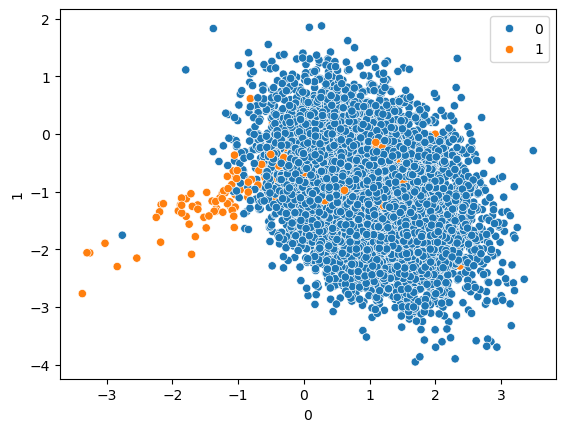

In [44]:
import pandas as pd
sns.scatterplot(x=pd.DataFrame(X)[0],y=pd.DataFrame(X)[1],hue=y)

In [10]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [29]:
#Hyperparameter Tunning
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
penalty=['l1', 'l2', 'elasticnet']
c_values=[0.001, 0.01, 0.1, 1.0, 10, 100]
solver=['lbfgs', 'liblinear', 'newton-cg', 'sag', 'saga']
class_weight=[{0:w,1:y} for w in [1,10,50,100] for y in [1,10,50,100]]

In [30]:
params = dict(penalty= penalty,C=c_values,solver=solver,class_weight=class_weight)

In [31]:
params

{'penalty': ['l1', 'l2', 'elasticnet'],
 'C': [0.001, 0.01, 0.1, 1.0, 10, 100],
 'solver': ['lbfgs', 'liblinear', 'newton-cg', 'sag', 'saga'],
 'class_weight': [{0: 1, 1: 1},
  {0: 1, 1: 10},
  {0: 1, 1: 50},
  {0: 1, 1: 100},
  {0: 10, 1: 1},
  {0: 10, 1: 10},
  {0: 10, 1: 50},
  {0: 10, 1: 100},
  {0: 50, 1: 1},
  {0: 50, 1: 10},
  {0: 50, 1: 50},
  {0: 50, 1: 100},
  {0: 100, 1: 1},
  {0: 100, 1: 10},
  {0: 100, 1: 50},
  {0: 100, 1: 100}]}

In [45]:
from sklearn.model_selection import StratifiedKFold
cv = StratifiedKFold()
from sklearn.model_selection import GridSearchCV
grid =GridSearchCV(estimator=LogisticRegression(),param_grid=params,scoring='accuracy',cv=cv,n_jobs=-1)

In [46]:
grid.fit(X_train,y_train)

,estimator,LogisticRegression()
,param_grid,"{'C': [100, 10, ...], 'penalty': ['l1', 'l2', ...], 'solver': ['lbfgs', 'liblinear', ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo...shuffle=False)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l1'


In [47]:
y_pred = grid.predict(X_test)

In [48]:
grid.best_params_

{'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}

In [49]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [50]:
score = accuracy_score(y_test,y_pred)
print(score)
cm = confusion_matrix(y_test,y_pred)
print(cm)
print(classification_report(y_test,y_pred))

0.79
[[82 18  4]
 [ 4 69 22]
 [ 6  9 86]]
              precision    recall  f1-score   support

           0       0.89      0.79      0.84       104
           1       0.72      0.73      0.72        95
           2       0.77      0.85      0.81       101

    accuracy                           0.79       300
   macro avg       0.79      0.79      0.79       300
weighted avg       0.80      0.79      0.79       300



In [51]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression

# Create Classification Dataset
from sklearn.datasets import make_classification

# Train Test Split
from sklearn.model_selection import train_test_split

# ROC Curve and ROC-AUC Score
from sklearn.metrics import roc_curve, roc_auc_score
from matplotlib import pyplot

In [52]:
X,y = make_classification(n_samples=1000,n_classes=2,random_state=1)

In [53]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [54]:
#Created Dummy model as ) from y_test
dummy_model_prob = [0 for _ in range(len(y_test))]

In [55]:
model = LogisticRegression()
model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [56]:
#Prediction based on probability
model_prob= model.predict_proba(X_test)

In [57]:
#Lets focus on the positive outcome
model_prob= model_prob[0:,1]

In [58]:
dummy_model_auc = roc_auc_score(y_test,dummy_model_prob)
model_auc =roc_auc_score(y_test,model_prob)
print(dummy_model_auc)
print(model_auc)

0.5
0.9108885464817668


In [59]:
dummy_fpr,dummy_tpr, _=roc_curve(y_test,dummy_model_prob)
model_fpr,model_tpr, thresholds = roc_curve(y_test,model_prob)

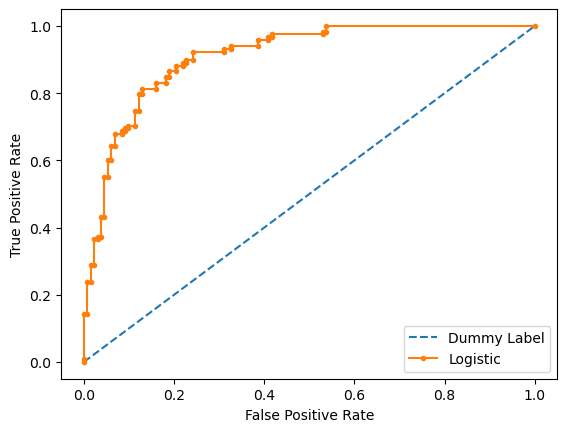

In [60]:
pyplot.plot(dummy_fpr,dummy_tpr,linestyle='--',label='Dummy Label')
pyplot.plot(model_fpr,model_tpr,marker='.',label='Logistic')
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
pyplot.legend()

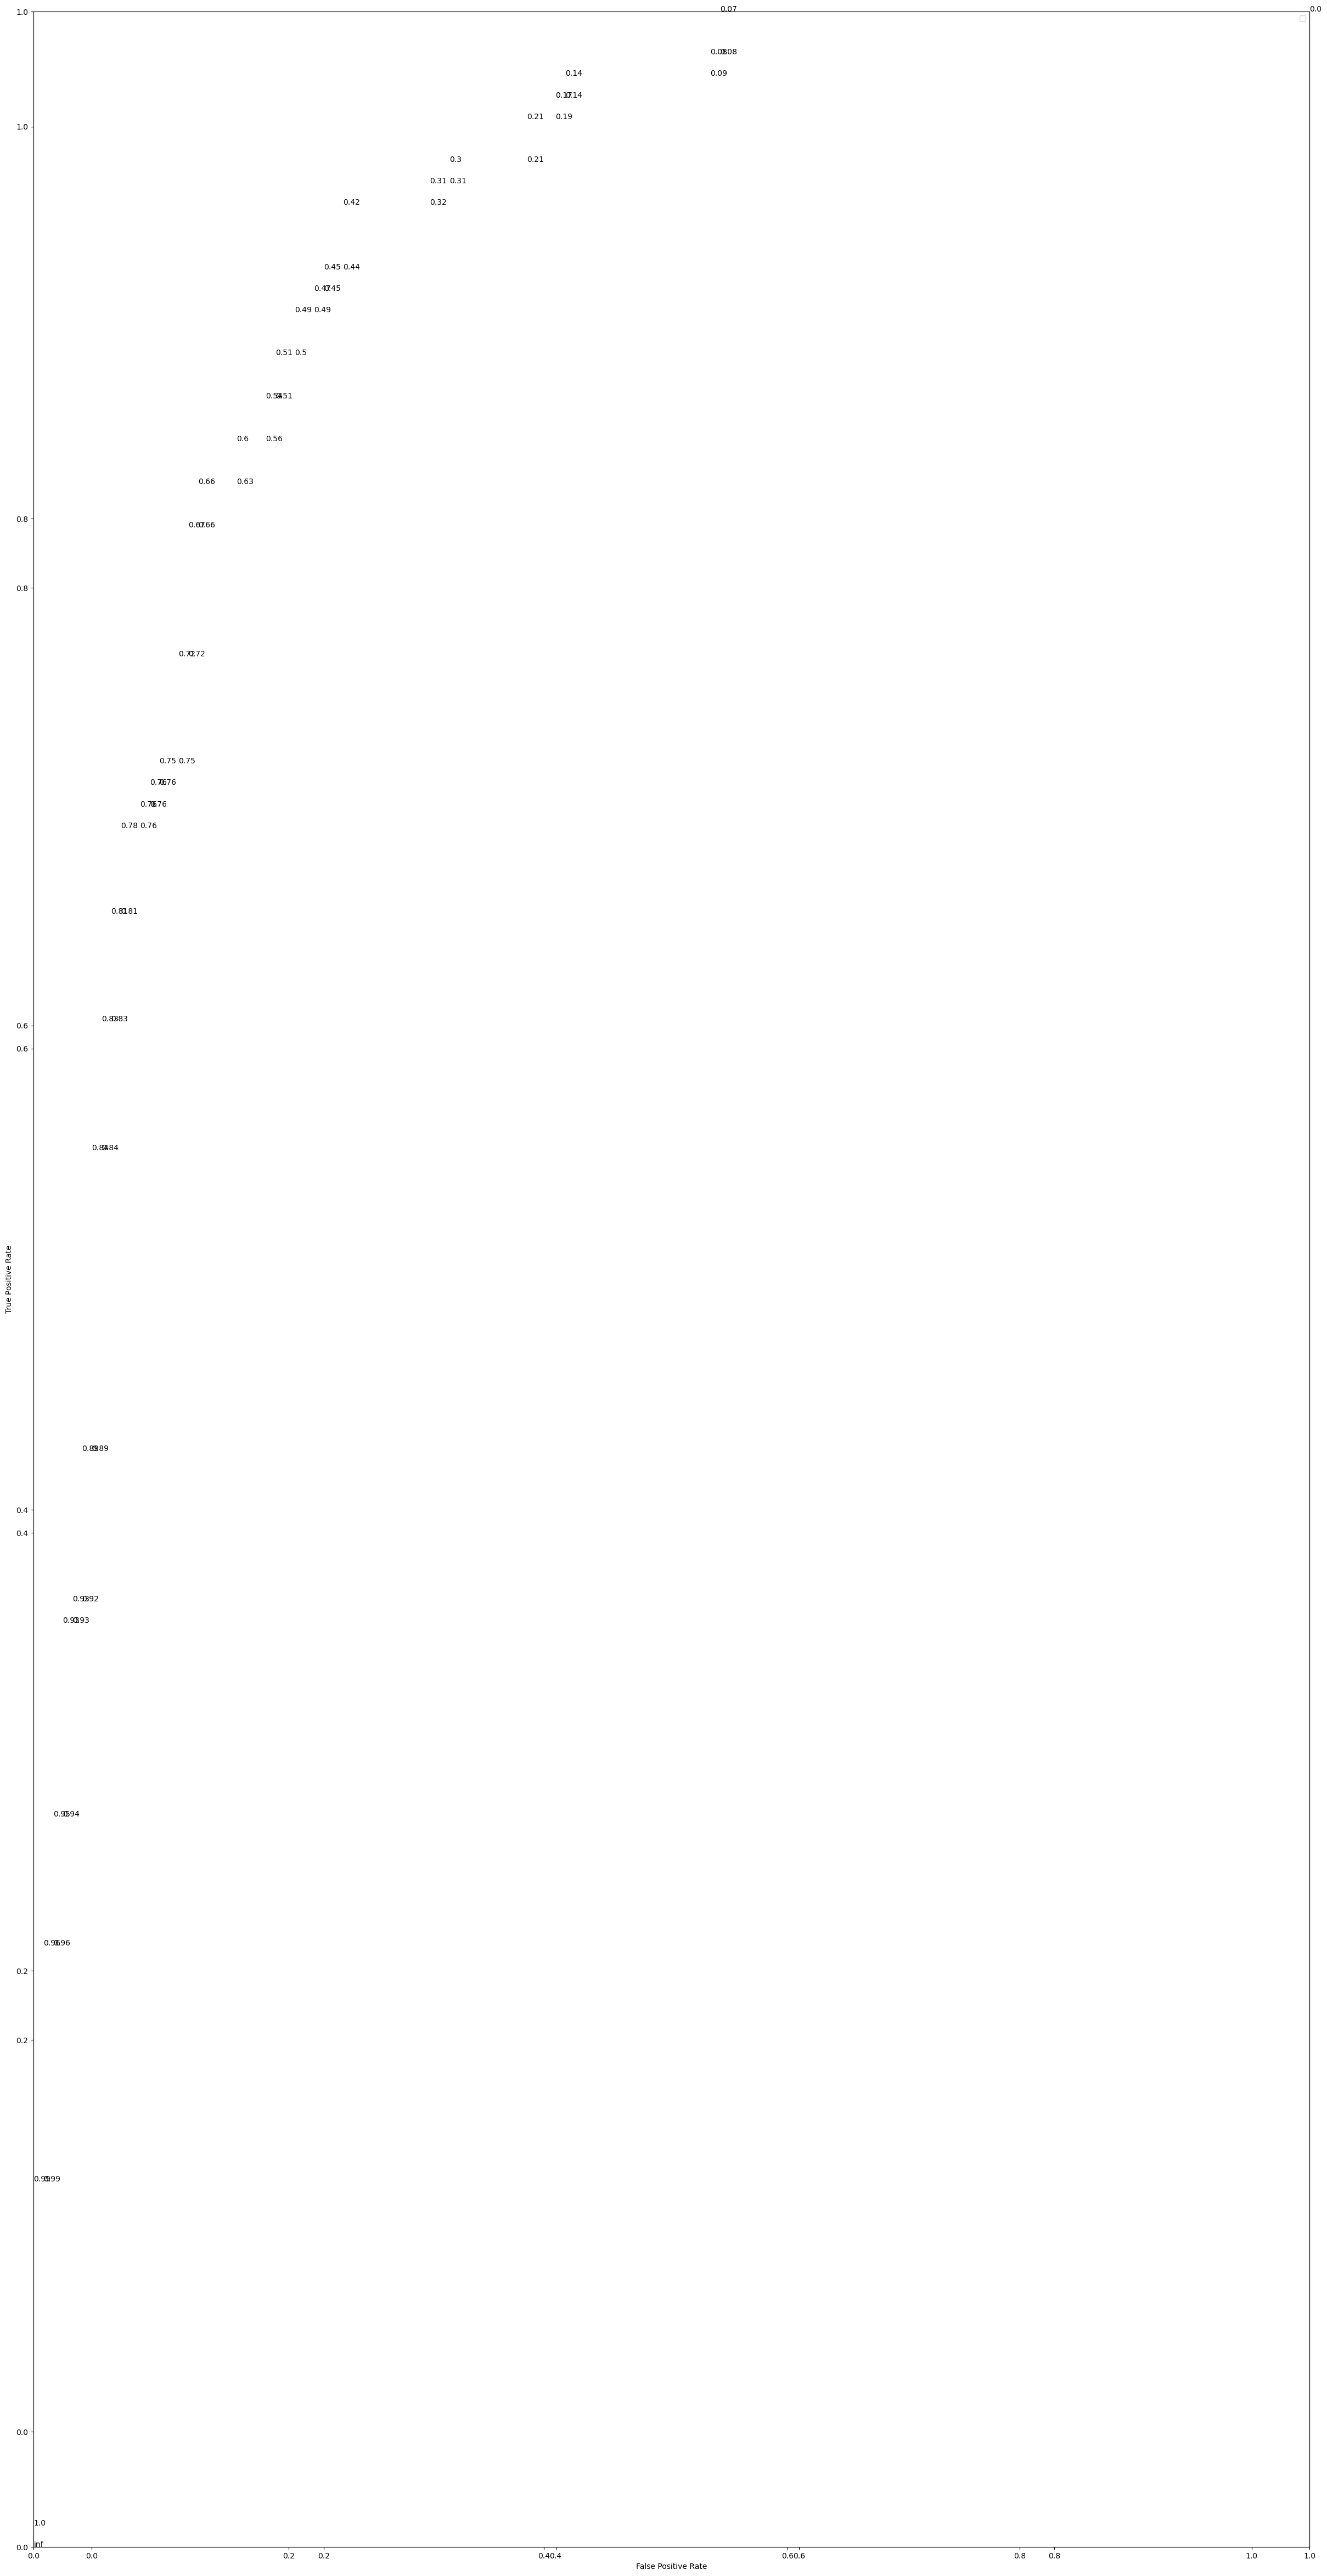

In [61]:
import numpy as np
fig = pyplot.figure(figsize=(30,60))
pyplot.plot(dummy_fpr,dummy_tpr,linestyle='--',label='Dummy Label')
pyplot.plot(model_fpr,model_tpr,marker='.',label='Logistic')
ax= fig.add_subplot(111)
for xyz in zip(model_fpr,model_tpr,thresholds):
    ax.annotate('%s' % np.round(xyz[2],2),xy=(xyz[0],xyz[1]))
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
pyplot.legend()
pyplot.show()